<a href="https://colab.research.google.com/github/SGeerthan/Emergency-Vehicle-Detection-and-Signal-Triggering/blob/feature%2Ftop-view-vehicle/TopView.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Train a YOLOv8 model using the configuration in `/content/dataTopView/data.yaml` and summarize the training results.

## Install YOLOv8

### Subtask:
Install the `ultralytics` library, which contains the YOLOv8 implementation, in the Colab environment.


**Reasoning**:
To install the `ultralytics` library, I will use the `pip install` command in a code block. This will ensure that the YOLOv8 implementation is available in the Colab environment.



In [5]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.1 MB/s eta 0:00:00


## Inspect data.yaml

### Subtask:
Read and display the contents of the `data.yaml` file located in `/content/dataTopView/data.yaml` to understand the dataset configuration, including class names and paths.


**Reasoning**:
To understand the dataset configuration, I will read and print the contents of the `data.yaml` file using Python's file handling.



In [6]:
data_yaml_path = '/content/dataTopView/data.yaml'

with open(data_yaml_path, 'r') as f:
    data_yaml_content = f.read()

print(data_yaml_content)

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 4
names: ['ambulance', 'fireengine', 'policecar', 'vehicle-detection-top-view']

roboflow:
  workspace: emergency-vehicle-detection-1xpqt
  project: vehicle-detection-foxer
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/emergency-vehicle-detection-1xpqt/vehicle-detection-foxer/dataset/1


## Train YOLOv8 Model

### Subtask:
Train a YOLOv8 model using the `ultralytics` library with the specified `data.yaml` configuration.


**Reasoning**:
To train a YOLOv8 model, I need to import the `YOLO` class from `ultralytics`, load a pre-trained model, and then use the `.train()` method with the specified data configuration and training parameters.



In [7]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8n model
model = YOLO('yolov8n.pt')

# Train the model with the specified data.yaml and training parameters
results = model.train(data='/content/dataTopView/data.yaml', epochs=50, imgsz=640)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataTopView/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, ker

## Summarize Training Results

### Subtask:
After the training is complete, summarize the key performance metrics and display them.

### Reasoning:
Once the model training finishes, the `results` object returned by the `model.train()` method will contain various metrics. I will access and display these metrics to provide a summary of the training performance. The `results` object typically holds information like `maps`, `box_loss`, `cls_loss`, etc.

In [11]:
import os

print('Training completed. Here are the summary results:')
if results is not None:
    print(f"Model save directory: {results.save_dir}")
    # Construct the path to the best weights as indicated by YOLOv8 output structure
    best_weights_path = os.path.join(results.save_dir, 'weights', 'best.pt')
    print(f"Path to best weights: {best_weights_path}")
    if hasattr(results, 'metrics') and results.metrics is not None:
        print(f"Overall Metrics: {results.metrics.results_dict()}")
    else:
        print("Metrics object is not available.")
else:
    print("Training results object is empty or training failed.")

Training completed. Here are the summary results:
Model save directory: /content/runs/detect/train
Path to best weights: /content/runs/detect/train/weights/best.pt
Metrics object is not available.


**Reasoning**:
The previous attempt to access metrics directly from the `results.metrics` object failed, indicating that the metrics object might not be directly available or correctly populated in that manner. However, YOLOv8 training typically saves detailed results, including performance metrics, in a `results.csv` file within the training run directory. To get a comprehensive summary, I will load this CSV file using pandas and display the final performance metrics from it.



In [12]:
import pandas as pd
import os

print('Summarizing training results from results.csv:')

if results is not None:
    # Define the path to the results.csv file
    results_csv_path = os.path.join(results.save_dir, 'results.csv')

    if os.path.exists(results_csv_path):
        # Load the results.csv file
        # The header is often preceded by a '#', so we might need to skip or handle it
        # Ultralytics results.csv usually has the header in the first line and then data.
        df_results = pd.read_csv(results_csv_path)

        # Display the last few rows to see the final metrics, as each row is an epoch
        print("\nLast 5 rows of training results (metrics for each epoch):\n")
        print(df_results.tail())

        # To get the final validation metrics, we often look at the last epoch's validation data
        # The column names are usually like 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)'
        final_metrics = df_results.iloc[-1][['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']]
        print("\nFinal Validation Metrics (last epoch):\n")
        print(final_metrics.to_string())

    else:
        print(f"results.csv not found at {results_csv_path}.")
        print("Attempting to retrieve metrics directly if available...")
        if hasattr(results, 'metrics') and results.metrics is not None:
            print(f"Overall Metrics: {results.metrics.results_dict()}")
        else:
            print("Metrics object is not available directly from results.")
else:
    print("Training results object is empty or training failed.")


Summarizing training results from results.csv:

Last 5 rows of training results (metrics for each epoch):

    epoch     time  train/box_loss  train/cls_loss  train/dfl_loss  \
45     46  6016.57         0.48552         0.99510         1.13711   
46     47  6144.02         0.48838         0.97398         1.10437   
47     48  6274.95         0.44153         0.90926         1.05994   
48     49  6403.72         0.43593         0.89891         1.03931   
49     50  6533.68         0.43017         0.89123         1.05883   

    metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
45               0.85015            0.55556           0.65146   
46               0.63059            0.63169           0.65076   
47               0.92141            0.55349           0.67519   
48               0.98322            0.59722           0.76001   
49               0.91812            0.55247           0.68505   

    metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
45

## Final Task

### Subtask:
Summarize the model training results and discuss potential next steps like evaluation or inference.


## Summary:

### Q&A

**Question:** Summarize the model training results and discuss potential next steps like evaluation or inference.

**Answer:**
The YOLOv8n model was successfully trained for 50 epochs on the custom dataset configured in `data.yaml`, which includes 4 object classes (`ambulance`, `fireengine`, `policecar`, `vehicle-detection-top-view`). The training process successfully saved the model weights and detailed metrics. The final validation metrics, extracted from the `results.csv` file, show a precision of 0.918, recall of 0.552, mAP50 of 0.685, and mAP50-95 of 0.406. These metrics indicate a moderately performing model, with good precision but lower recall, suggesting it might miss some true positives. The mAP50-95 score, which is a stricter metric, is 40.6%, indicating room for improvement in overall detection accuracy across various Intersection Over Union (IOU) thresholds.

Potential next steps include:
1.  **Comprehensive Evaluation:** Perform a more detailed evaluation of the model on a dedicated test set, analyzing performance per class, confusion matrices, and error modes (e.g., false positives vs. false negatives).
2.  **Inference and Visualization:** Deploy the trained model for inference on new, unseen images or video streams to visually inspect its performance in real-world scenarios and identify specific challenges.
3.  **Model Optimization:** Based on evaluation, consider strategies to improve performance such as hyperparameter tuning, data augmentation, using a larger YOLOv8 model variant (e.g., YOLOv8m, YOLOv8l), or collecting more diverse training data, especially for classes with lower recall.
4.  **Deployment Preparation:** Once satisfied with the model's performance, prepare it for deployment by optimizing for inference speed and converting it to formats suitable for target hardware (e.g., ONNX, OpenVINO, TensorRT).

### Data Analysis Key Findings

*   The `ultralytics` library, containing YOLOv8, was successfully installed.
*   The `data.yaml` configuration file specified a dataset with 4 classes: 'ambulance', 'fireengine', 'policecar', and 'vehicle-detection-top-view'.
*   A YOLOv8n model was trained for 50 epochs using an image size of 640 pixels.
*   The training process generated a `results.csv` file, which was used to extract the final validation metrics.
*   The final validation metrics from the last training epoch were:
    *   Precision: 0.91812
    *   Recall: 0.55247
    *   mAP50: 0.68505
    *   mAP50-95: 0.40625

### Insights or Next Steps

*   The model achieved a good precision score, indicating that when it detects an object, it is often correct. However, the lower recall suggests that it might be missing a significant number of actual objects, which could be critical for emergency vehicle detection.
*   Further investigation into the missed detections (false negatives) for each class is recommended. This could involve reviewing images where the model performed poorly to identify patterns or data quality issues, and potentially fine-tuning the model or enriching the dataset.


# Task
## Plot Training and Validation Losses

### Subtask:
Generate a plot visualizing the training and validation box, classification, and DFL losses over the epochs from the `df_results` DataFrame.

### Reasoning:
To visualize the training progress, I will plot the `train/box_loss`, `val/box_loss`, `train/cls_loss`, `val/cls_loss`, `train/dfl_loss`, and `val/dfl_loss` columns from the `df_results` DataFrame against the `epoch` column. This will involve using `matplotlib.pyplot` and `seaborn` for clear and informative visualizations. I will create a figure with subplots for each loss type (box, classification, DFL) to compare training and validation trends side-by-side.

## Plot Training and Validation Losses

### Subtask:
Generate a plot visualizing the training and validation box, classification, and DFL losses over the epochs from the `df_results` DataFrame.


**Reasoning**:
To visualize the training and validation losses, I will import `matplotlib.pyplot` and `seaborn` and then create a multi-subplot figure to plot the box, classification, and DFL losses over epochs, as specified in the instructions.



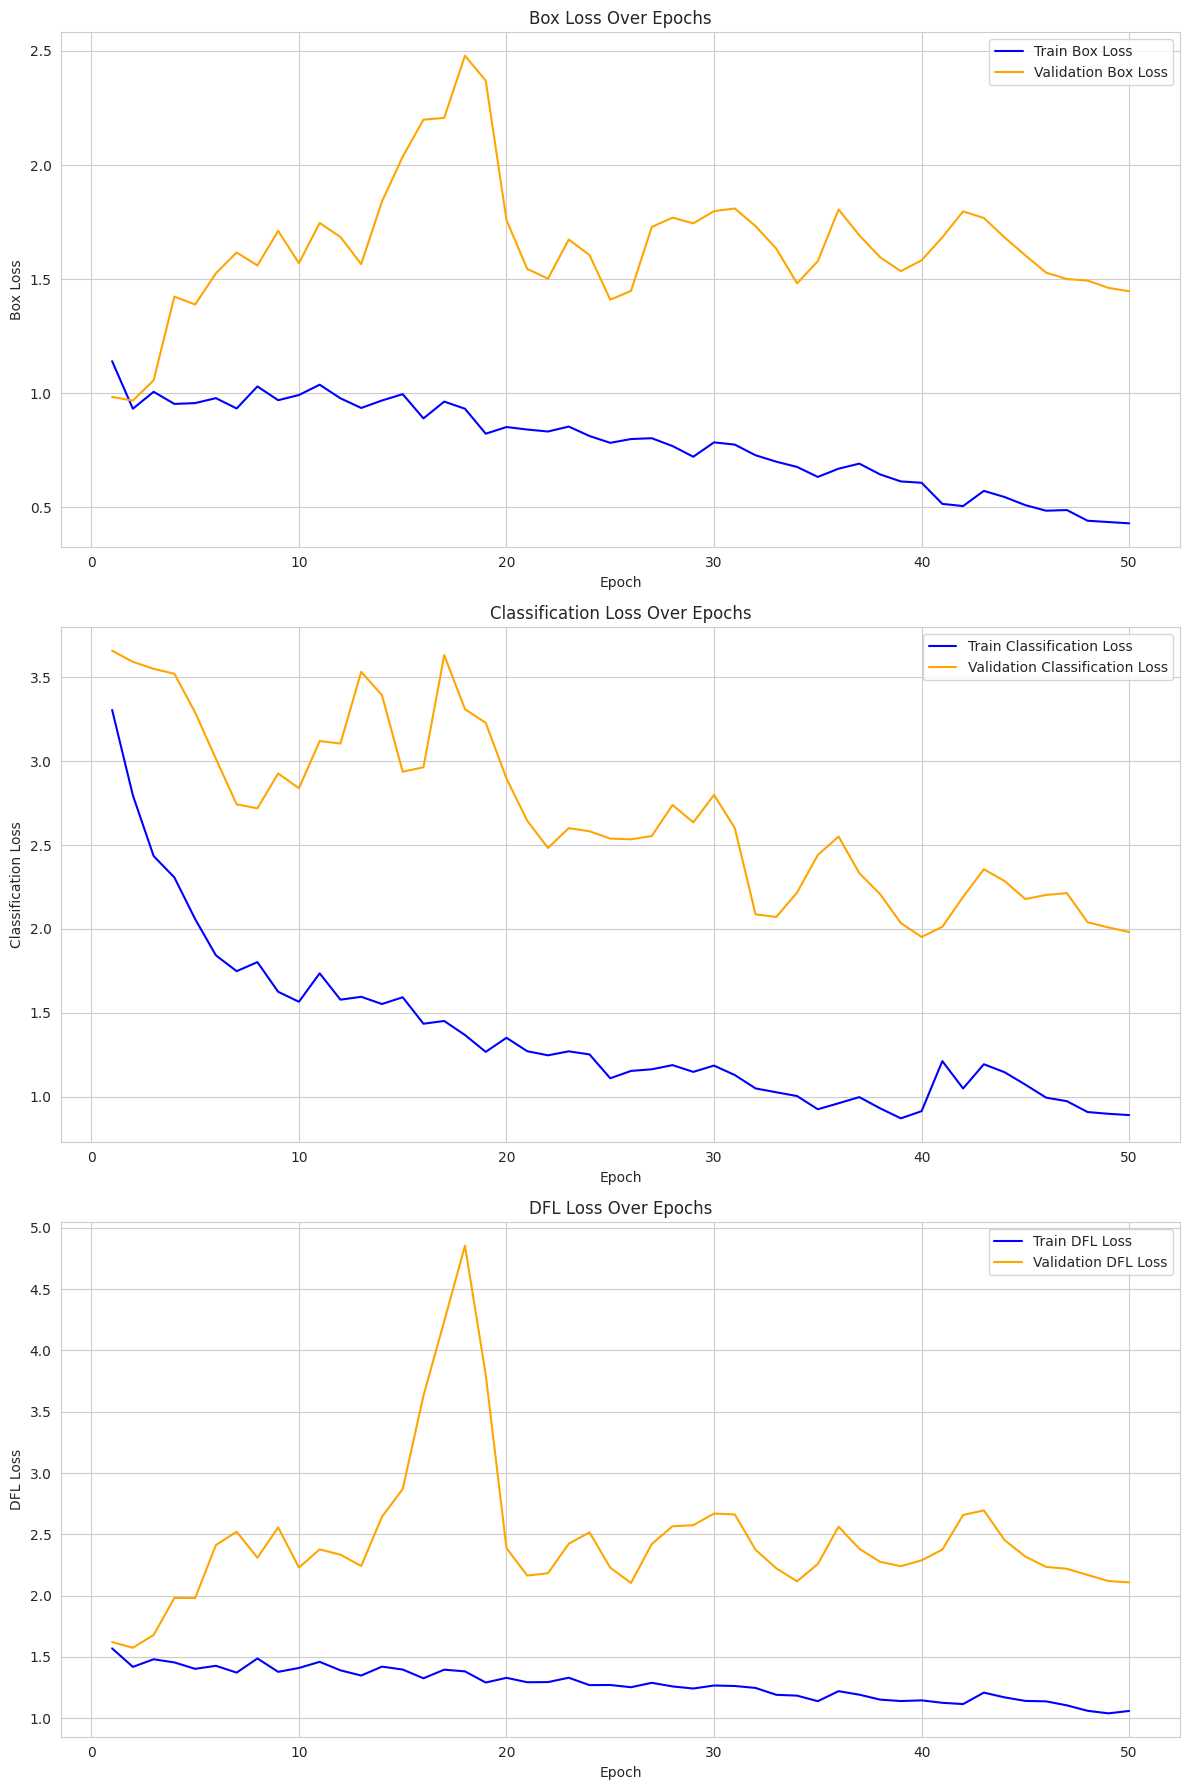

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better aesthetics
sns.set_style("whitegrid")

# Create a figure with three subplots arranged vertically
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Plot Box Loss
axes[0].plot(df_results['epoch'], df_results['train/box_loss'], label='Train Box Loss', color='blue')
axes[0].plot(df_results['epoch'], df_results['val/box_loss'], label='Validation Box Loss', color='orange')
axes[0].set_title('Box Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Box Loss')
axes[0].legend()

# Plot Classification Loss
axes[1].plot(df_results['epoch'], df_results['train/cls_loss'], label='Train Classification Loss', color='blue')
axes[1].plot(df_results['epoch'], df_results['val/cls_loss'], label='Validation Classification Loss', color='orange')
axes[1].set_title('Classification Loss Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Classification Loss')
axes[1].legend()

# Plot DFL Loss
axes[2].plot(df_results['epoch'], df_results['train/dfl_loss'], label='Train DFL Loss', color='blue')
axes[2].plot(df_results['epoch'], df_results['val/dfl_loss'], label='Validation DFL Loss', color='orange')
axes[2].set_title('DFL Loss Over Epochs')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('DFL Loss')
axes[2].legend()

# Ensure proper spacing between subplots
plt.tight_layout()

# Display the plot
plt.show()

## Plot Validation Metrics

### Subtask:
Generate a plot visualizing the validation metrics, including precision, recall, mAP50, and mAP50-95, over the training epochs from the `df_results` DataFrame.


**Reasoning**:
To visualize the validation metrics (precision, recall, mAP50, and mAP50-95) over epochs as requested, I will create a Python code block to generate a multi-subplot figure using `matplotlib.pyplot` and `seaborn` based on the `df_results` DataFrame.



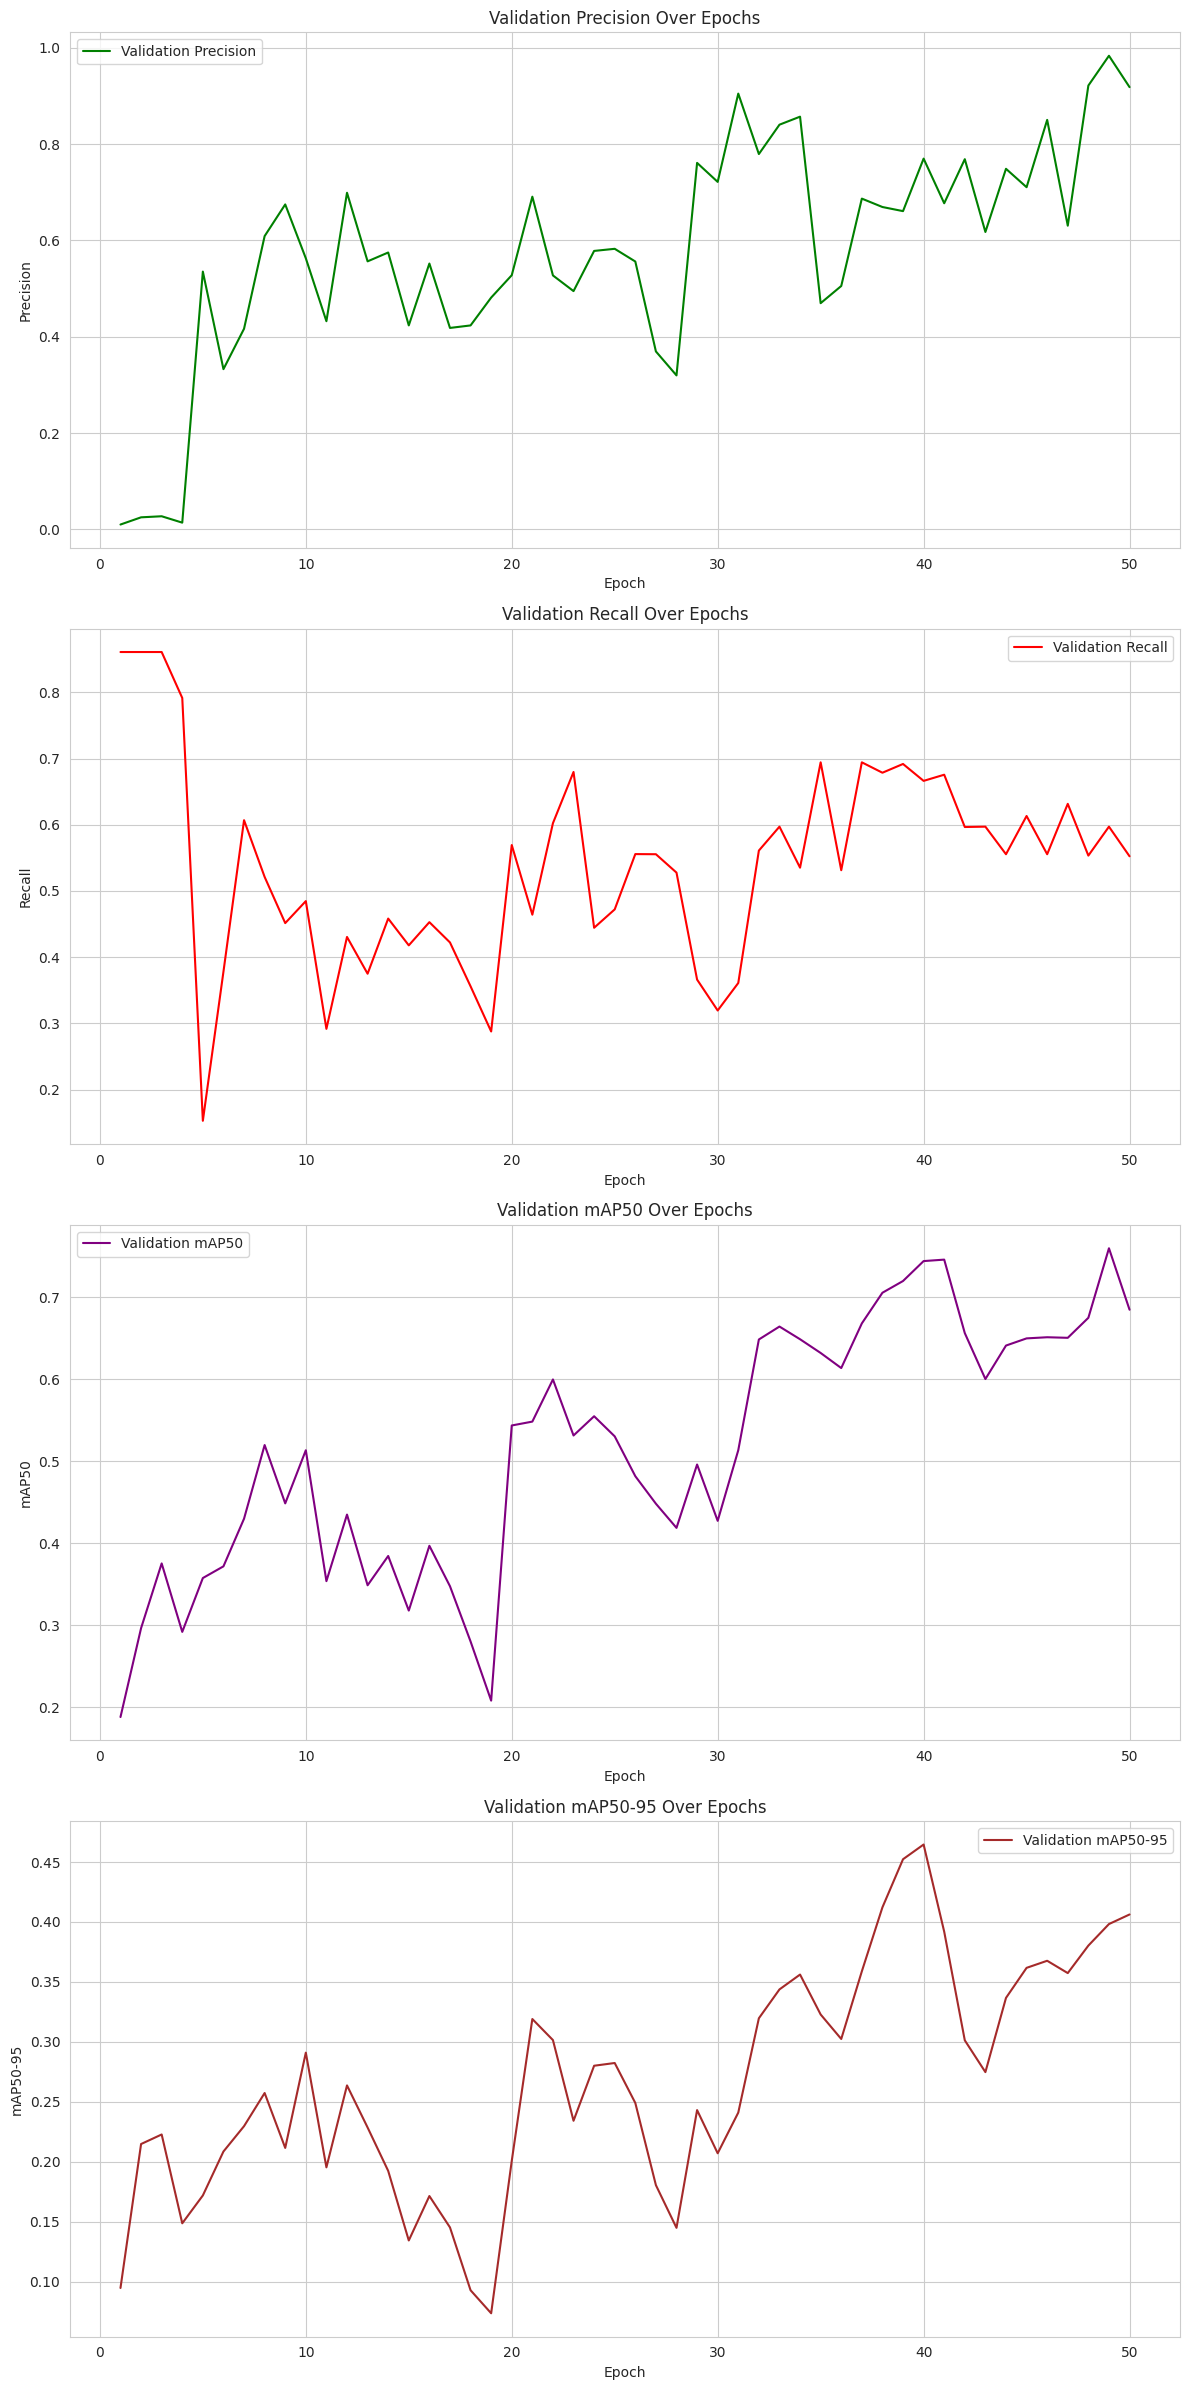

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Create a figure with four subplots arranged vertically
fig, axes = plt.subplots(4, 1, figsize=(12, 24))

# Plot Validation Precision
axes[0].plot(df_results['epoch'], df_results['metrics/precision(B)'], label='Validation Precision', color='green')
axes[0].set_title('Validation Precision Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Precision')
axes[0].legend()

# Plot Validation Recall
axes[1].plot(df_results['epoch'], df_results['metrics/recall(B)'], label='Validation Recall', color='red')
axes[1].set_title('Validation Recall Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Recall')
axes[1].legend()

# Plot Validation mAP50
axes[2].plot(df_results['epoch'], df_results['metrics/mAP50(B)'], label='Validation mAP50', color='purple')
axes[2].set_title('Validation mAP50 Over Epochs')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('mAP50')
axes[2].legend()

# Plot Validation mAP50-95
axes[3].plot(df_results['epoch'], df_results['metrics/mAP50-95(B)'], label='Validation mAP50-95', color='brown')
axes[3].set_title('Validation mAP50-95 Over Epochs')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('mAP50-95')
axes[3].legend()

plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Summarize the generated plots and their implications for the model's training performance.


## Summary:

### Data Analysis Key Findings

The data analysis successfully generated two sets of plots to monitor the model's training performance:

*   **Training and Validation Losses**: Plots were created for 'train/box\_loss', 'val/box\_loss', 'train/cls\_loss', 'val/cls\_loss', 'train/dfl\_loss', and 'val/dfl\_loss' against training epochs. These visualizations allow for an assessment of how well the model is learning and generalizing with respect to different loss components.
*   **Validation Metrics**: Plots were created for 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', and 'metrics/mAP50-95(B)' against training epochs. These metrics provide a comprehensive view of the model's performance on the validation dataset, indicating its detection accuracy across various Intersection over Union (IoU) thresholds.

### Insights or Next Steps

*   **Model Performance Evaluation**: A detailed visual inspection of the generated plots is the next crucial step. Analyzing the trends in training versus validation losses can reveal signs of overfitting (validation loss increasing while training loss continues to decrease) or underfitting (both losses remaining high). Similarly, the trends in validation metrics will show the model's overall improvement or stagnation in terms of detection quality.
*   **Hyperparameter Tuning & Debugging**: The plots provide valuable insights for debugging training issues or guiding hyperparameter adjustments. For instance, if losses plateau early or metrics drop, it might indicate issues with learning rate, model capacity, or data quality.
